In [28]:
# Library for dataframe reading
import pandas as pd

# Library for visualizations 
import seaborn as sns

# Library for SQL queries
import getpass

import pg8000


In [29]:
# connecting to the database 
login = input('Login username: ')
secret = getpass.getpass()

credentials = {'user'    : login,
               'password': secret, 
               'database': 'csci403',
               'host'    : 'ada.mines.edu'}

db = pg8000.connect(**credentials)

cursor = db.cursor()

In [30]:
# DATA EXPLORATION: what is the average trip duration for each start and end station pair in the dataset?

# NOTE: before performing the data aggregation, there was a view created to obtain a 
# subset of the data (see in queries.sql)

# perform data aggregation
average_trip_query = """
SELECT start_station_name,
end_station_name,
       AVG(trip_duration)
FROM subset_trip
WHERE end_station_name IS NOT NULL 
AND start_station_name IS NOT NULL
AND end_station_name is NOT NULL
GROUP BY start_station_name, end_station_name
ORDER BY end_station_name

"""
cursor.execute(average_trip_query)

# fetch results from aggregation
average_trip = cursor.fetchall()

# convert list to visual dataframe (Easier for reading exact data)
average_trip = pd.DataFrame(average_trip, columns=["start","end","avg_trip_duration"])

In [31]:
# converting avg to a numeric column
average_trip.info()
average_trip["avg_trip_duration"] = pd.to_numeric(average_trip['avg_trip_duration'])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19209 entries, 0 to 19208
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   start              19209 non-null  object
 1   end                19209 non-null  object
 2   avg_trip_duration  19209 non-null  object
dtypes: object(3)
memory usage: 450.3+ KB


In [32]:
# Checking to see if conversion was successful
average_trip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19209 entries, 0 to 19208
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   start              19209 non-null  object 
 1   end                19209 non-null  object 
 2   avg_trip_duration  19209 non-null  float64
dtypes: float64(1), object(2)
memory usage: 450.3+ KB


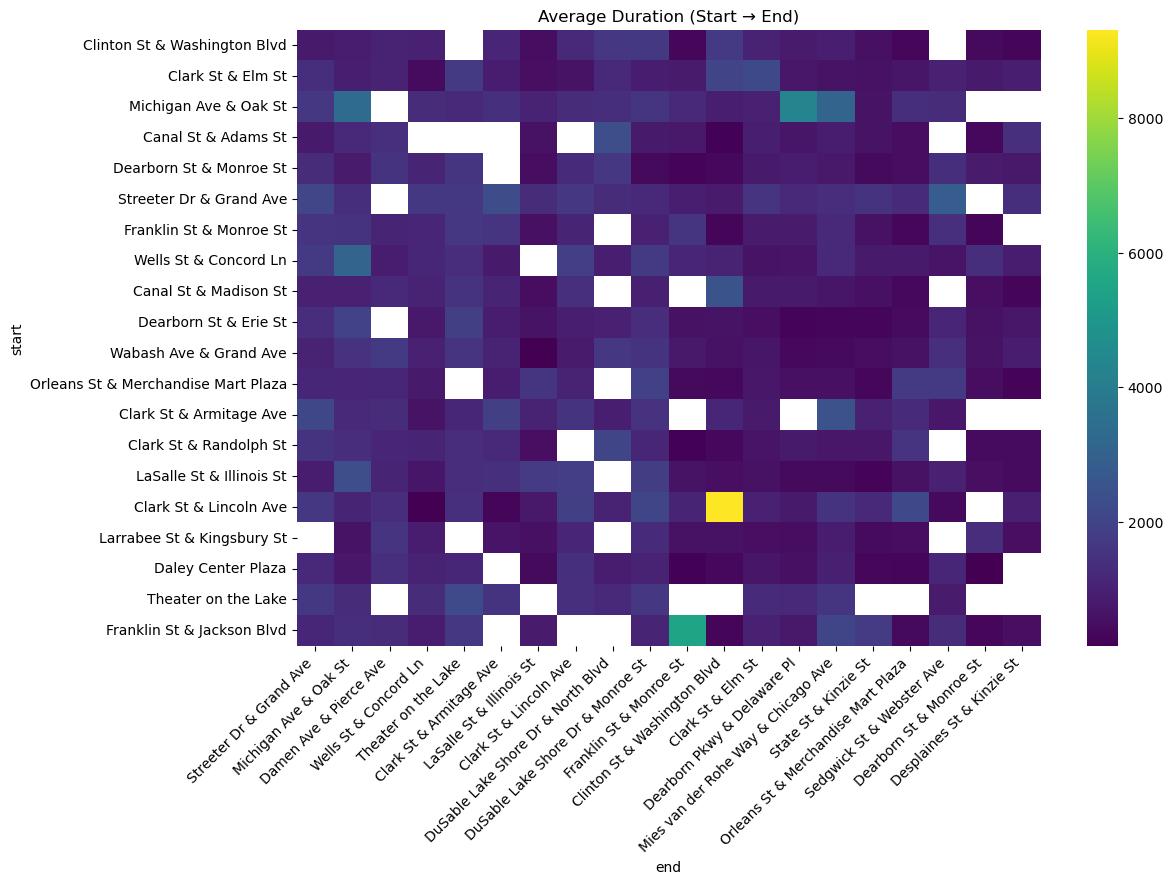

In [33]:
# NOTE: creating a heat-map to show which commute (to and from) are the longest

import matplotlib.pyplot as plt
# pivot into matrix form
pivot = average_trip.pivot(index='start', columns='end', values='avg_trip_duration')

# optional: reduce size (top N most common starts/ends)
top_starts = average_trip['start'].value_counts().head(20).index
top_ends = average_trip['end'].value_counts().head(20).index
pivot = pivot.loc[top_starts, top_ends]

plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap='viridis')
plt.title("Average Duration (Start → End)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

In [34]:
# DATA EXPLORATION: what is the average trip duration by gender?

avg_trip_gender_query = """
SELECT start_station_name,
gender,
end_station_name,
       AVG(trip_duration)
FROM subset_trip
WHERE end_station_name IS NOT NULL 
AND gender <> -1
AND start_station_name IS NOT NULL
AND end_station_name is NOT NULL
GROUP BY gender, start_station_name, end_station_name
ORDER BY end_station_name
                        """
cursor.execute(avg_trip_gender_query)

average_trip_gender = cursor.fetchall()

average_trip_gender = pd.DataFrame(average_trip_gender, columns=["start_location","gender","end_location","avg_trip_duration"])
average_trip_gender["avg_trip_duration"] = pd.to_numeric(average_trip_gender['avg_trip_duration'])

In [35]:
average_trip_gender.head(10000)

,start_location,gender,end_location,avg_trip_duration
0,900 W Harrison St,0,900 W Harrison St,735.000000
1,Wolcott Ave & Polk St,0,900 W Harrison St,513.000000
2,Halsted St & Maxwell St,1,900 W Harrison St,336.000000
3,Morgan St & 18th St,0,900 W Harrison St,468.000000
4,Ogden Ave & Congress Pkwy,1,900 W Harrison St,660.000000
...,...,...,...,...
9995,Wells St & Erie St,0,Lakeview Ave & Fullerton Pkwy,794.333333
9996,Morgan St & Lake St*,0,Lakeview Ave & Fullerton Pkwy,1155.333333
9997,State St & Wacker Dr,0,Lakeview Ave & Fullerton Pkwy,1310.000000
9998,Broadway & Cornelia Ave,0,Lakeview Ave & Fullerton Pkwy,695.000000


In [36]:
df = average_trip_gender.copy()

# make sure numeric
df['avg_trip_duration'] = pd.to_numeric(df['avg_trip_duration'], errors='coerce')
df = df.dropna(subset=['avg_trip_duration'])

# make gender readable
df['gender_label'] = df['gender'].map({0: 'Female', 1: 'Male'})


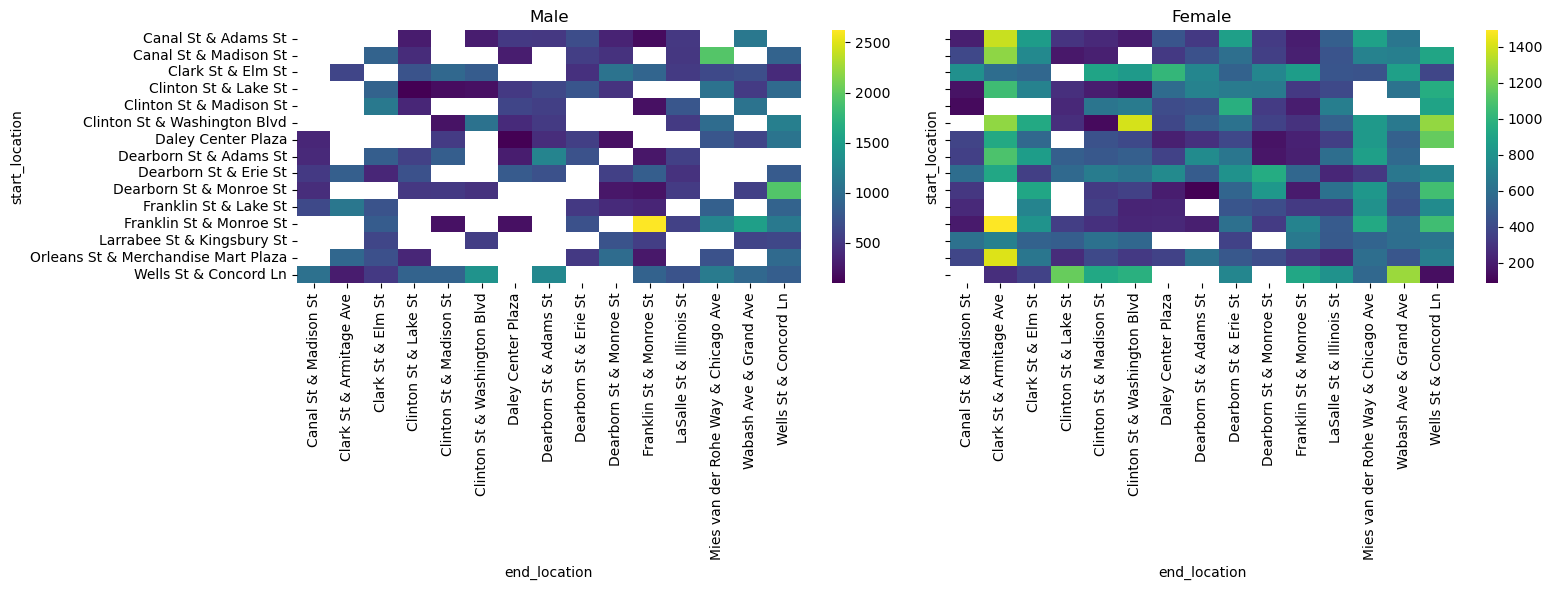

In [37]:
# reduce size so plot is readable
top_starts = df['start_location'].value_counts().head(15).index
top_ends = df['end_location'].value_counts().head(15).index

df_small = df[
    df['start_location'].isin(top_starts) &
    df['end_location'].isin(top_ends)
]

genders = df_small['gender_label'].dropna().unique()

fig, axes = plt.subplots(1, len(genders), figsize=(16,6), sharey=True)

# handle case where only one gender exists
if len(genders) == 1:
    axes = [axes]

for ax, gender in zip(axes, genders):
    subset = df_small[df_small['gender_label'] == gender]
    
    pivot = subset.pivot(
        index='start_location',
        columns='end_location',
        values='avg_trip_duration'
    )
    
    sns.heatmap(pivot, cmap='viridis', ax=ax)
    ax.set_title(gender)

plt.tight_layout()
plt.show()

Research Question: Is there a difference in average trip duartion for each start and end location pair between male and female Divvy bike users? 

$H_0$: For any given start–end pair, males and females have the same average trip duration.
$H_a$: For at least some routes, males and females have different average trip durations.

In [38]:
pivot = df.pivot_table(
    index=['start_location','end_location'],
    columns='gender_label',
    values='avg_trip_duration'
).dropna()

diff = pivot['Female'] - pivot['Male']

from scipy.stats import ttest_1samp
t_stat, p_value = ttest_1samp(diff, 0)

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: -12.331637400749134
p-value: 2.510775006850135e-34


/Users/ariderritt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ariderritt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Female', ylabel='Count'>

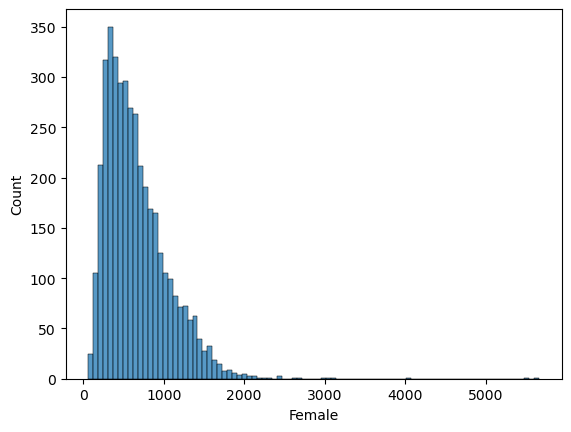

In [39]:
# Distribution of Female Avg trip duration
pivot['Female']
sns.histplot(pivot['Female'])

/Users/ariderritt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ariderritt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Male', ylabel='Count'>

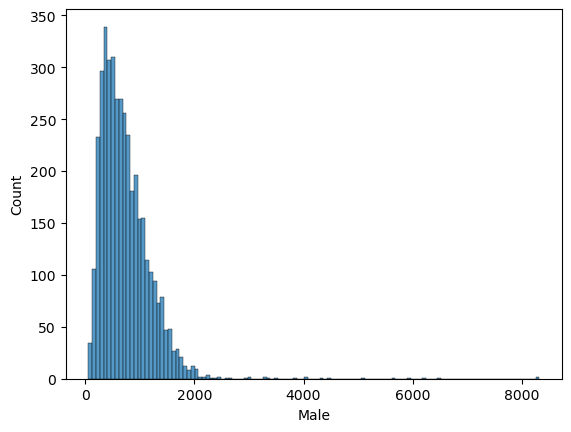

In [40]:
# Distribution of male trip duration
sns.histplot(pivot['Male'])

Conclusion: There is statistically significant evidence that for at least some routes in the data, males and females have different trip averages. 

Reasearch Question: Is gender a good predictor of the average time between specific stations in Chicago?

Research Question: Is user type (casual or member) a good predictor of the average time between specific stations in chicago?

Research Question: is the docking point capacity of the start station a good predictor of the average time between specific stations in Chicago? what about the end station?


In [41]:
import statsmodels.formula.api as smf

model = smf.ols(
    'avg_trip_duration ~ C(start_location) + C(end_location) + C(gender)',
    data=average_trip_gender
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      avg_trip_duration   R-squared:                       0.101
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     3.622
Date:                Sun, 03 May 2026   Prob (F-statistic):          2.65e-162
Time:                        12:29:47   Log-Likelihood:            -1.5030e+05
No. Observations:               19796   AIC:                         3.018e+05
Df Residuals:                   19201   BIC:                         3.065e+05
Df Model:                         594                                         
Covariance Type:            nonrobust                                         
                                                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

In [42]:
from scipy.stats import f_oneway

groups = [
    group['avg_trip_duration'].values
    for _, group in df.groupby('gender_label')
]

f_stat, p_val = f_oneway(*groups)

In [43]:
p_val

1.5228886916525438e-09

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

df = average_trip_gender.copy()

# features + target
X = df[['start_location', 'end_location', 'gender']]
y = df['avg_trip_duration']

# preprocessing (encode categories)
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['start_location','end_location','gender'])
    ]
)

model = Pipeline([
    ('prep', preprocess),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


print("RMSE:", mean_squared_error(y_test, preds, squared=False))

ValueError: Found input variables with inconsistent numbers of samples: [3960, 3859]

In [ ]:
df['avg_trip_duration'].mean()

790.7971243243448

/Users/ariderritt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ariderritt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='avg_trip_duration', ylabel='Count'>

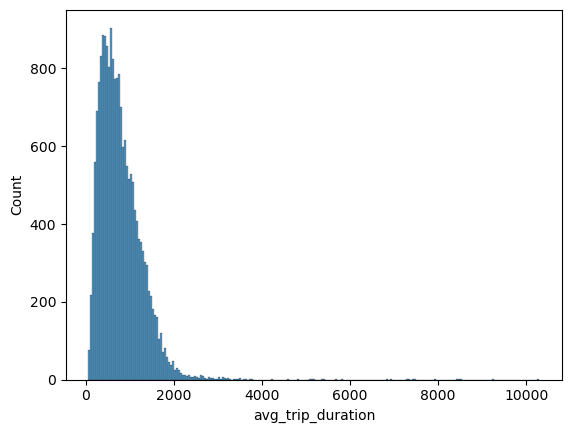

In [ ]:
sns.histplot(df['avg_trip_duration'])

The mean trip time for each Only using start location, end location, and gender is not enough to predict the average trip duration between stations in Chicago.

/var/folders/_b/stcy7nh162df13sw49nfqh7r0000gn/T/ipykernel_13614/1623538380.py:5: RuntimeWarning: overflow encountered in expm1
  preds = np.expm1(preds_log)


ValueError: Input contains infinity or a value too large for dtype('float64').